[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Padding and Stride

The previous notebook left us with a fact we now need to control: convolution shrinks its input.  With an $n_\textrm{h} \times n_\textrm{w}$ input and a $k_\textrm{h} \times k_\textrm{w}$ kernel the output is $(n_\textrm{h}-k_\textrm{h}+1) \times (n_\textrm{w}-k_\textrm{w}+1)$, because the window can only be placed where it fits entirely inside the image.

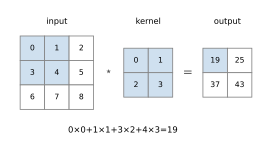

In [12]:
# this figure is drawn rather than linked, so the notebook needs no network
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')              # crisp vector output
except ImportError:
    pass

# Shared idiom for the grid figures of this module.  Geometry is in inches and
# the axes are set so one data unit is one inch, so text never outgrows a cell.
CELL = 0.34
SHADE = '#cfe0ef'          # cells taking part in the highlighted computation
SHADE2 = '#f3ddd0'         # a second, distinct computation
PAD_FILL = '0.955'         # padding added around the input
FS = 7.6

def _grid(ax, x0, y0, values, shade=(), shade2=(), pad=(), cell=CELL, fs=FS,
          colors=None, z=2):
    """Draw a matrix with its top-left cell's top-left corner at (x0, y0).

    `z` sets the drawing order, so overlapping channel slices occlude cleanly.
    """
    from matplotlib.patches import Rectangle
    shade, shade2, pad = set(shade), set(shade2), set(pad)
    colors = colors or {}
    for r, row in enumerate(values):
        for c, v in enumerate(row):
            fill = colors.get((r, c),
                              SHADE if (r, c) in shade else
                              SHADE2 if (r, c) in shade2 else
                              PAD_FILL if (r, c) in pad else 'white')
            ax.add_patch(Rectangle((x0 + c * cell, y0 - (r + 1) * cell),
                                   cell, cell, facecolor=fill,
                                   edgecolor='0.5', linewidth=0.8, zorder=z))
            if v is not None:
                ax.text(x0 + (c + 0.5) * cell, y0 - (r + 0.5) * cell, str(v),
                        ha='center', va='center', fontsize=fs,
                        color='0.55' if (r, c) in pad else 'black', zorder=z + 1)
    return len(values[0]) * cell, len(values) * cell


def _label(ax, x, y, text, fs=8.2, weight='normal'):
    ax.text(x, y, text, ha='center', va='center', fontsize=fs, fontweight=weight)


def _op(ax, x, y, symbol):
    ax.text(x, y, symbol, ha='center', va='center', fontsize=12, color='0.35')


def _finish(fig, ax, x0, x1, y0, y1):
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.axis('off')
    fig.set_size_inches(x1 - x0, y1 - y0)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)


def _row_layout(panels, gap=0.42, top=0.0):
    """Left-to-right x positions for a row of (width, height) panels."""
    xs, cursor = [], 0.0
    for w, h in panels:
        xs.append(cursor)
        cursor += w + gap
    return xs, cursor - gap


# ---------------------------------------------------------------- 03_02 / 03_03

def cross_correlation_figure():
    """Input, kernel and output of a 2-D cross-correlation, with one window shaded."""
    X = [[0, 1, 2], [3, 4, 5], [6, 7, 8]]
    K = [[0, 1], [2, 3]]
    Y = [[19, 25], [37, 43]]

    fig, ax = plt.subplots()
    top = 0.0
    x = 0.0
    w1, h1 = _grid(ax, x, top, X, shade=[(0, 0), (0, 1), (1, 0), (1, 1)])
    _label(ax, x + w1 / 2, top + 0.20, 'input')
    x1 = x + w1
    _op(ax, x1 + 0.21, top - h1 / 2, r'$\star$')
    x2 = x1 + 0.42
    w2, h2 = _grid(ax, x2, top - (h1 - 2 * CELL) / 2, K,
                   shade=[(0, 0), (0, 1), (1, 0), (1, 1)])
    _label(ax, x2 + w2 / 2, top + 0.20, 'kernel')
    x3 = x2 + w2
    _op(ax, x3 + 0.21, top - h1 / 2, '=')
    x4 = x3 + 0.42
    w3, h3 = _grid(ax, x4, top - (h1 - 2 * CELL) / 2, Y, shade=[(0, 0)])
    _label(ax, x4 + w3 / 2, top + 0.20, 'output')

    ax.text((x4 + w3) / 2, top - h1 - 0.30,
            r'$0\times0 + 1\times1 + 3\times2 + 4\times3 = 19$',
            ha='center', va='center', fontsize=8.4)
    _finish(fig, ax, -0.18, x4 + w3 + 0.18, top - h1 - 0.52, top + 0.40)

cross_correlation_figure()

A couple of pixels per layer sounds harmless; over a deep network it is not.  Starting from a $240 \times 240$ image, ten layers of $5 \times 5$ convolutions leave $200 \times 200$ — thirty percent of the image gone, and with it any information near the boundaries.  **Padding** is the standard fix.

The opposite problem also arises.  Sometimes we *want* to reduce resolution quickly, either because the input is unwieldy or because coarser feature maps are what a deeper layer should be looking at.  **Strided convolutions** do that.

Between them, these two knobs give complete control over the output size of a convolutional layer, which is what makes it possible to design an architecture on paper — as we will do for LeNet in notebook 6.

In [1]:
# render figures as crisp vector graphics (SVG) in the notebook
try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('svg')
except ImportError:
    pass

import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'   # keep text as text in the SVG

import torch
from torch import nn

## Padding

The shrinkage has a second, subtler cost: pixels near the boundary participate in fewer output values than pixels in the middle.  The figure below shows how often each pixel is used, for kernels of size $1 \times 1$, $2 \times 2$ and $3 \times 3$.  The corners are barely consulted at all.

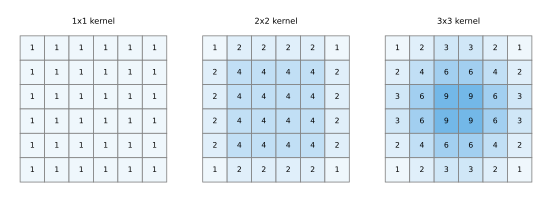

In [13]:
def pixel_reuse_figure():
    """How many output values each input pixel contributes to, for three kernel sizes."""
    n = 6
    fig, ax = plt.subplots()
    x, top = 0.0, 0.0
    hi = 3 * 3        # shared scale, so the three panels are comparable
    for k in (1, 2, 3):
        counts = [[min(i + 1, k, n - k + 1, n - i) * min(j + 1, k, n - k + 1, n - j)
                   for j in range(n)] for i in range(n)]
        ramp = {(i, j): (1 - 0.55 * counts[i][j] / hi,
                         1 - 0.28 * counts[i][j] / hi,
                         1 - 0.09 * counts[i][j] / hi)
                for i in range(n) for j in range(n)}
        w, h = _grid(ax, x, top, counts, colors=ramp)
        _label(ax, x + w / 2, top + 0.20, f'{k}x{k} kernel')
        x += w + 0.50
    _finish(fig, ax, -0.18, x - 0.50 + 0.18, top - 6 * CELL - 0.22, top + 0.40)

pixel_reuse_figure()

The remedy is to add extra pixels around the boundary of the input, increasing its effective size.  Typically the added pixels are zero.  Below, a $3 \times 3$ input is padded to $5 \times 5$, and the output correspondingly grows to $4 \times 4$.  The shaded portions are the first output element and the input and kernel elements it uses: $0\times0+0\times1+0\times2+0\times3=0$.

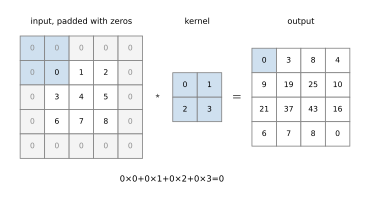

In [14]:
def padding_figure():
    """The same operation on a zero-padded input: a 3x3 input gives a 4x4 output."""
    Xp = [[0, 0, 0, 0, 0],
          [0, 0, 1, 2, 0],
          [0, 3, 4, 5, 0],
          [0, 6, 7, 8, 0],
          [0, 0, 0, 0, 0]]
    padded = [(r, c) for r in range(5) for c in range(5)
              if r in (0, 4) or c in (0, 4)]
    K = [[0, 1], [2, 3]]
    Y = [[0, 3, 8, 4], [9, 19, 25, 10], [21, 37, 43, 16], [6, 7, 8, 0]]

    fig, ax = plt.subplots()
    top, x = 0.0, 0.0
    w1, h1 = _grid(ax, x, top, Xp, shade=[(0, 0), (0, 1), (1, 0), (1, 1)],
                   pad=padded)
    _label(ax, x + w1 / 2, top + 0.20, 'input, padded with zeros')
    x1 = x + w1
    _op(ax, x1 + 0.21, top - h1 / 2, r'$\star$')
    x2 = x1 + 0.42
    w2, h2 = _grid(ax, x2, top - (h1 - 2 * CELL) / 2, K,
                   shade=[(0, 0), (0, 1), (1, 0), (1, 1)])
    _label(ax, x2 + w2 / 2, top + 0.20, 'kernel')
    x3 = x2 + w2
    _op(ax, x3 + 0.21, top - h1 / 2, '=')
    x4 = x3 + 0.42
    w3, h3 = _grid(ax, x4, top - (h1 - 4 * CELL) / 2, Y, shade=[(0, 0)])
    _label(ax, x4 + w3 / 2, top + 0.20, 'output')

    ax.text((x4 + w3) / 2, top - h1 - 0.30,
            r'$0\times0 + 0\times1 + 0\times2 + 0\times3 = 0$',
            ha='center', va='center', fontsize=8.4)
    _finish(fig, ax, -0.18, x4 + w3 + 0.18, top - h1 - 0.52, top + 0.40)

padding_figure()

Rather than take the shrinkage on faith, here is the window actually moving.  The helper below animates one convolution: the kernel slides over the (padded) input on the left, and each position it visits fills in one cell of the output on the right.  Change the numbers and re-run it — that is the point of writing it as a function.

In [15]:
import io, json, re, uuid
from string import Template
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import HTML

PAD_FILL = '0.90'        # the zero padding
DONE_FILL = '#9ecae1'    # output cells already computed
LIVE = '#c0392b'         # the current window, and the output cell it produces

# matplotlib's to_jshtml() embeds each frame as a bitmap, which pins the
# animation to whatever resolution it was rendered at.  We save the frames as
# SVG instead and swap them in with a few lines of JavaScript, so they stay
# sharp at any zoom.  Only one frame is in the page at a time, which also
# avoids the duplicate element ids that matplotlib puts in every SVG.
PLAYER = Template("""
<div id="$uid" style="max-width:${width}px;margin:0.5em 0">
  <div id="$uid-frame"></div>
  <div style="display:flex;gap:0.6em;align-items:center;
              font:13px/1.4 system-ui,sans-serif;color:#333">
    <button id="$uid-play" style="width:2.2em;cursor:pointer">&#9208;</button>
    <input type="range" id="$uid-slider" min="0" max="$last" value="0"
           style="flex:1;cursor:pointer">
    <span id="$uid-label" style="min-width:5em;text-align:right;
          font-variant-numeric:tabular-nums"></span>
  </div>
</div>
<script>
(function() {
  var frames = $frames, i = 0, timer = null;
  var box = document.getElementById("$uid-frame"),
      play = document.getElementById("$uid-play"),
      slider = document.getElementById("$uid-slider"),
      label = document.getElementById("$uid-label");

  function show(k) {
    i = (k + frames.length) % frames.length;
    box.innerHTML = frames[i];
    slider.value = i;
    label.textContent = (i + 1) + " / " + frames.length;
  }
  function start() {
    timer = setInterval(function() { show(i + 1); }, $interval);
    play.innerHTML = "&#9208;";
  }
  function stop() {
    clearInterval(timer); timer = null; play.innerHTML = "&#9654;";
  }
  play.onclick = function() { timer ? stop() : start(); };
  slider.oninput = function() { stop(); show(+slider.value); };
  show(0); start();
})();
</script>
""")

def svg_player(fig, update, frames, fps=2, width=900):
    """Render `frames` frames of `fig` to SVG and return an HTML player.
    `update(i)` draws frame i, exactly as it would for FuncAnimation."""
    svgs = []
    for i in range(frames):
        update(i)
        buf = io.StringIO()
        fig.savefig(buf, format='svg')
        svg = buf.getvalue()
        svg = svg[svg.index('<svg'):]              # drop the XML preamble
        svg = re.sub(r'width="[\d.]+pt" height="[\d.]+pt"',
                     'width="100%" height="auto"', svg, count=1)
        svgs.append(svg)
    return PLAYER.substitute(
        uid='p' + uuid.uuid4().hex[:8], last=frames - 1, width=width,
        interval=int(1000 / fps),
        frames=json.dumps(svgs).replace('</', r'<\/'))   # safe inside <script>

def slide_animation(size=5, kernel_size=3, padding=0, stride=1, fps=2):
    """Animate a kernel sliding over a padded input, filling in the output.
    One frame per output position."""
    n = size + 2 * padding
    if n < kernel_size:
        raise ValueError(f'a {kernel_size}x{kernel_size} kernel does not fit '
                         f'in a {n}x{n} padded input')
    steps = list(range(0, n - kernel_size + 1, stride))
    positions = [(i, j) for i in steps for j in steps]
    out = len(steps)

    fig = plt.figure(figsize=(8.2, 3.9))
    ax_in = fig.add_axes([0.03, 0.16, 0.44, 0.68])
    ax_out = fig.add_axes([0.60, 0.16, 0.30, 0.68])
    for ax, m in ((ax_in, n), (ax_out, out)):
        # a hair of margin: without it the outer cell borders sit exactly on
        # the axes limits and half of each is clipped away
        ax.set_xlim(-0.06, m + 0.06); ax.set_ylim(m + 0.06, -0.06)
        ax.set_aspect('equal'); ax.axis('off')

    # the input grid; padding cells are grey and hold a zero
    for i in range(n):
        for j in range(n):
            pad_cell = (i < padding or j < padding
                        or i >= n - padding or j >= n - padding)
            ax_in.add_patch(Rectangle((j, i), 1, 1, lw=1.0, edgecolor='0.65',
                                      facecolor=PAD_FILL if pad_cell else 'white'))
            if pad_cell:
                ax_in.text(j + 0.5, i + 0.5, '0', ha='center', va='center',
                           fontsize=8, color='0.55')
    if padding:                      # outline where the original image sits
        ax_in.add_patch(Rectangle((padding, padding), size, size, fill=False,
                                  edgecolor='0.35', lw=1.6, zorder=4))

    # the output grid, filled in as the window visits each position
    out_cells = []
    for i in range(out):
        for j in range(out):
            cell = Rectangle((j, i), 1, 1, facecolor='white',
                             edgecolor='0.65', lw=1.0)
            ax_out.add_patch(cell)
            out_cells.append(cell)

    cover = Rectangle((0, 0), kernel_size, kernel_size, facecolor=LIVE,
                      alpha=0.16, edgecolor=LIVE, lw=2.2, zorder=5)
    ax_in.add_patch(cover)

    ax_in.set_title(f'input {size}x{size}'
                    + (f', padded to {n}x{n}' if padding else ''),
                    fontsize=9.5, color='0.3')
    ax_out.set_title(f'output {out}x{out}', fontsize=9.5, color='0.3')
    fig.text(0.5, 0.50, '$\\rightarrow$', ha='center', va='center',
             fontsize=20, color='0.6')
    fig.text(0.5, 0.95, f'kernel {kernel_size}x{kernel_size}   '
             f'padding {padding}   stride {stride}', ha='center', fontsize=10,
             color='0.15')
    fig.text(0.5, 0.02, f'output = ⌊({size} + 2·{padding} − {kernel_size}) '
             f'/ {stride}⌋ + 1 = {out}', ha='center', fontsize=9.5,
             color='0.35')
    status = fig.text(0.5, 0.095, '', ha='center', fontsize=9, color=LIVE)

    def update(frame):
        # rebuild the state from the frame index, so scrubbing backwards works
        i, j = positions[frame]
        cover.set_xy((j, i))
        for idx, cell in enumerate(out_cells):
            cell.set_facecolor(DONE_FILL if idx < frame else
                               LIVE if idx == frame else 'white')
        r, c = divmod(frame, out)
        status.set_text(f'window at row {i}, column {j}   →   '
                        f'output[{r}, {c}]')

    html = svg_player(fig, update, len(positions), fps=fps)
    plt.close(fig)
    return HTML(html)

In [16]:
slide_animation(size=5, kernel_size=3, padding=0)

Nine windows fit, so a $5 \times 5$ input becomes a $3 \times 3$ output — a ring of pixels has been lost.  Watch the corners as it plays: the top-left pixel is covered by exactly one window, while a pixel in the middle is covered by nine.  That is the uneven pixel utilization of the previous figure, seen from the other side.

Now the same input and the same kernel, with one pixel of zero padding:

In [17]:
slide_animation(size=5, kernel_size=3, padding=1)

Twenty-five windows, and the output is $5 \times 5$ — the same size as the input.  The grey ring is the padding, the darker outline marks where the original image sits inside it, and the corner pixel is now covered by four windows rather than one.

Adding a total of $p_\textrm{h}$ rows of padding (roughly half at the top, half at the bottom) and $p_\textrm{w}$ columns (half left, half right) gives an output of shape

$$(n_\textrm{h}-k_\textrm{h}+p_\textrm{h}+1)\times(n_\textrm{w}-k_\textrm{w}+p_\textrm{w}+1),$$

so height and width each grow by exactly the amount of padding added.

The case worth memorizing is $p_\textrm{h}=k_\textrm{h}-1$ and $p_\textrm{w}=k_\textrm{w}-1$, which makes the output the same size as the input.  Layers that preserve shape are much easier to stack, since you can add or remove one without recomputing every subsequent size.

This is where the near-universal preference for **odd** kernel sizes — 1, 3, 5, 7 — comes from.  With $k_\textrm{h}$ odd, $p_\textrm{h} = k_\textrm{h}-1$ is even and we can pad $p_\textrm{h}/2$ rows on *each* side, keeping the arrangement symmetric.  (With an even kernel we would have to pad $\lceil p_\textrm{h}/2\rceil$ on top and $\lfloor p_\textrm{h}/2\rfloor$ on the bottom, an asymmetry with no benefit.)  Symmetric padding also gives a clean interpretation: the output `Y[i, j]` is the cross-correlation of the kernel with the window *centered* on `X[i, j]`.

Let's check the arithmetic.  A $3 \times 3$ kernel with 1 pixel of padding on all sides, applied to an $8 \times 8$ input, should give back $8 \times 8$:

In [5]:
def comp_conv2d(conv2d, X):
    """Apply a conv layer to a 2D input, handling the rank-4 bookkeeping.
    Adds the batch and channel axes, applies the layer, strips them off."""
    X = X.reshape((1, 1) + X.shape)
    Y = conv2d(X)
    return Y.reshape(Y.shape[2:])

# padding=1 adds one row/column on either side, two in total per axis.
# The first argument of LazyConv2d is the number of *output* channels.
conv2d = nn.LazyConv2d(1, kernel_size=3, padding=1)
X = torch.rand(size=(8, 8))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

A kernel of size 5 needs padding 2 for the same effect — in general, padding $(k-1)/2$ for an odd kernel of size $k$:

In [6]:
conv2d = nn.LazyConv2d(1, kernel_size=5, padding=2)
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

Kernels need not be square, and neither need the padding.  A $5 \times 3$ kernel preserves shape with padding $(2, 1)$:

In [7]:
conv2d = nn.LazyConv2d(1, kernel_size=(5, 3), padding=(2, 1))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

## Stride

So far the window has moved one element at a time.  Sometimes we want it to move further — for computational efficiency, or deliberately to downsample.  This is especially natural with a large kernel, which already summarizes a large area, so that evaluating it at every position is largely redundant work.

The number of rows and columns traversed per slide is the **stride**.  The figure below shows a cross-correlation with a stride of 3 vertically and 2 horizontally.  The shaded portions give $0\times0+0\times1+1\times2+2\times3=8$ and $0\times0+6\times1+0\times2+0\times3=6$.  When the second element of the first column is produced, the window has slid down three rows; when the second element of the first row is produced, it has slid two columns right.  Sliding two more columns produces nothing, because the input can no longer fill the window.

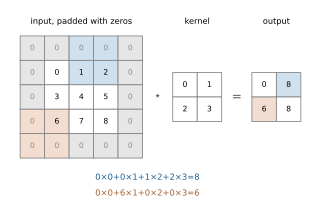

In [18]:
def stride_figure():
    """Stride 3 down and 2 across: two shaded windows show where the second row and column come from."""
    Xp = [[0, 0, 0, 0, 0],
          [0, 0, 1, 2, 0],
          [0, 3, 4, 5, 0],
          [0, 6, 7, 8, 0],
          [0, 0, 0, 0, 0]]
    padded = [(r, c) for r in range(5) for c in range(5)
              if r in (0, 4) or c in (0, 4)]
    K = [[0, 1], [2, 3]]
    Y = [[0, 8], [6, 8]]

    fig, ax = plt.subplots()
    top, x = 0.0, 0.0
    w1, h1 = _grid(ax, x, top, Xp,
                   shade=[(0, 2), (0, 3), (1, 2), (1, 3)],
                   shade2=[(3, 0), (3, 1), (4, 0), (4, 1)], pad=padded)
    _label(ax, x + w1 / 2, top + 0.20, 'input, padded with zeros')
    x1 = x + w1
    _op(ax, x1 + 0.21, top - h1 / 2, r'$\star$')
    x2 = x1 + 0.42
    w2, h2 = _grid(ax, x2, top - (h1 - 2 * CELL) / 2, K)
    _label(ax, x2 + w2 / 2, top + 0.20, 'kernel')
    x3 = x2 + w2
    _op(ax, x3 + 0.21, top - h1 / 2, '=')
    x4 = x3 + 0.42
    w3, h3 = _grid(ax, x4, top - (h1 - 2 * CELL) / 2, Y,
                   shade=[(0, 1)], shade2=[(1, 0)])
    _label(ax, x4 + w3 / 2, top + 0.20, 'output')

    ax.text((x4 + w3) / 2, top - h1 - 0.28,
            r'$0\times0 + 0\times1 + 1\times2 + 2\times3 = 8$', ha='center',
            va='center', fontsize=8.4, color='#1f6091')
    ax.text((x4 + w3) / 2, top - h1 - 0.50,
            r'$0\times0 + 6\times1 + 0\times2 + 0\times3 = 6$', ha='center',
            va='center', fontsize=8.4, color='#a4602f')
    _finish(fig, ax, -0.18, x4 + w3 + 0.18, top - h1 - 0.72, top + 0.40)

stride_figure()

The same helper shows it, now with the stride left free.  Compare this with the padded run above: identical input, identical kernel, identical padding — the window simply moves two cells at a time instead of one.

In [19]:
slide_animation(size=7, kernel_size=3, padding=1, stride=2)

Sixteen windows instead of forty-nine, and a $7 \times 7$ input becomes a $4 \times 4$ output.  Notice that consecutive windows no longer overlap on every column: with stride 1 two neighbouring windows shared two of their three columns, and with stride 2 they share only one.  That is the sense in which a stride-1 convolution does redundant work.

With stride $s_\textrm{h}$ for the height and $s_\textrm{w}$ for the width, the output shape is

$$\lfloor(n_\textrm{h}-k_\textrm{h}+p_\textrm{h}+s_\textrm{h})/s_\textrm{h}\rfloor \times \lfloor(n_\textrm{w}-k_\textrm{w}+p_\textrm{w}+s_\textrm{w})/s_\textrm{w}\rfloor.$$

This is the general formula, and the two special cases worth remembering fall out of it.  Setting $p_\textrm{h}=k_\textrm{h}-1$ and $p_\textrm{w}=k_\textrm{w}-1$ simplifies it to $\lfloor(n_\textrm{h}+s_\textrm{h}-1)/s_\textrm{h}\rfloor \times \lfloor(n_\textrm{w}+s_\textrm{w}-1)/s_\textrm{w}\rfloor$; and if the input dimensions are divisible by the strides, that is just $(n_\textrm{h}/s_\textrm{h}) \times (n_\textrm{w}/s_\textrm{w})$ — a stride of 2 halves the resolution, which is the usual reason for using one.

Here is that halving:

In [9]:
conv2d = nn.LazyConv2d(1, kernel_size=3, padding=1, stride=2)
comp_conv2d(conv2d, X).shape

torch.Size([4, 4])

And a deliberately awkward case, to exercise the general formula:

In [10]:
conv2d = nn.LazyConv2d(1, kernel_size=(3, 5), padding=(0, 1), stride=(3, 4))
comp_conv2d(conv2d, X).shape

torch.Size([2, 2])

### The formula, checked

Rather than take the formula on faith, let's write it down and compare it against PyTorch over a range of configurations.  This function is also worth keeping: predicting output shapes on paper is how you design an architecture without running it.

In [11]:
def conv_output_shape(n, k, p=0, s=1):
    """Output side length of a convolution: input n, kernel k, total padding
    p (summed over both sides), stride s."""
    return (n - k + p + s) // s

# check against PyTorch for a range of configurations
n = 17
for k in (1, 2, 3, 5):
    for pad in (0, 1, 2):
        for s in (1, 2, 3):
            conv2d = nn.LazyConv2d(1, kernel_size=k, padding=pad, stride=s)
            actual = comp_conv2d(conv2d, torch.rand(n, n)).shape[0]
            # PyTorch's `padding` is per side, so the total is 2 * pad
            predicted = conv_output_shape(n, k, 2 * pad, s)
            assert actual == predicted, (k, pad, s, actual, predicted)
print('the formula agrees with PyTorch on all', 4 * 3 * 3, 'configurations')

the formula agrees with PyTorch on all 36 configurations


One consequence is worth pausing on.  With a stride of $s$, the receptive field of a unit grows by a factor of $s$ per layer instead of by a constant — the multiplicative growth promised at the end of the last notebook.  A stack of a few stride-2 layers sees the whole image, where a stack of stride-1 layers of the same depth would see a small patch.  This is why real architectures reduce resolution as they go deeper, and it is exactly the pattern we will see in LeNet.

## Summary and discussion

**Padding** increases the height and width of the output.  It is most often used to make the output the same size as the input, avoiding unwanted shrinkage and ensuring that boundary pixels are used about as often as interior ones.  We normally pad symmetrically, and when $p_\textrm{h} = p_\textrm{w}$ we simply speak of padding $p$.  The same convention applies to strides: when $s_\textrm{h} = s_\textrm{w}$ we speak of stride $s$.  A **stride** greater than one reduces the resolution of the output to roughly $1/s$ of the input along each axis.  By default PyTorch uses padding 0 and stride 1.

All the padding we discussed extends the image with zeros.  This has a real computational benefit — it is trivial to implement, and operators can exploit it implicitly without allocating memory.  It also, incidentally, lets a CNN encode absolute position: the network can learn where the zeros are, and thus how close a feature is to the boundary, which slightly undermines the translation invariance we designed for.  Alternatives to zero-padding exist (reflecting or replicating the boundary, or circular padding for periodic data) and are worth knowing about.

## Exercises

1. What are the computational benefits of a stride larger than 1?
2. What might be the *statistical* benefits of a stride larger than 1?  (Think about what neighboring outputs of a stride-1 convolution have in common.)
3. Given the last example in this notebook, compute the output shape by hand using the formula, and confirm it against the code.
4. For audio signals, what does a stride of 2 correspond to?
5. Implement mirror padding — reflecting the image at the boundary instead of filling with zeros — and compare the two on an edge-detection example.  Where do they differ, and why might reflection be preferable near a bright boundary?
6. Using `conv_output_shape`, work out the sequence of feature-map sizes for a network of five $3 \times 3$ convolutions with padding 1, where layers 2 and 4 use stride 2, starting from a $32 \times 32$ input.  How large is the receptive field of a unit in the final layer?